In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/home/alex/git/spectral_neuron_paper


# Univariate fitting

Thin wrapper around `paper.experiments.univariate`.


In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments.univariate import DEFAULT_RUNS_DIR, PROFILES, run_profile
from paper.plotting import plot_scaling, plot_target_gallery
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams['figure.dpi'] = 140


In [7]:
profile_name = 'full'
profile = PROFILES[profile_name]
raw_path = DEFAULT_RUNS_DIR / f"univariate_{profile_name}.csv"
summary_path = DEFAULT_RUNS_DIR / f"univariate_{profile_name}_summary.csv"
plot_target_kind = "general"

In [8]:
if raw_path.exists():
    raw = pd.read_csv(raw_path)
else:
    raw = run_profile(profile)
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(raw_path, index=False)

expected_models = {"unconstrained", "monotone"}
if not expected_models <= set(raw["model"].unique()):
    raise ValueError(f"{raw_path} does not contain {sorted(expected_models)}; rerun this profile")

summary = summarize_raw(raw, profile.budgets)
summary.to_csv(summary_path, index=False)
plot_summary = summary.loc[summary["target_kind"] == plot_target_kind].copy()
plot_summary.head()


,target_kind,complexity,noise_std,model,dim,eig_idx,budget,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,mean_test_rmse,n
0,general,5,0.0,unconstrained,5,2,1,0.1,0.796240,0.596269,1.022360,0.819537,96
1,general,5,0.0,unconstrained,5,2,2,0.1,0.614279,0.444385,0.849788,0.643640,96
2,general,5,0.0,unconstrained,5,2,5,0.1,0.543267,0.312861,0.679657,0.541703,96
3,general,5,0.0,unconstrained,5,2,10,0.1,0.381743,0.246046,0.599874,0.435436,96
4,general,5,0.0,unconstrained,5,2,20,0.1,0.263861,0.177213,0.426769,0.316857,96


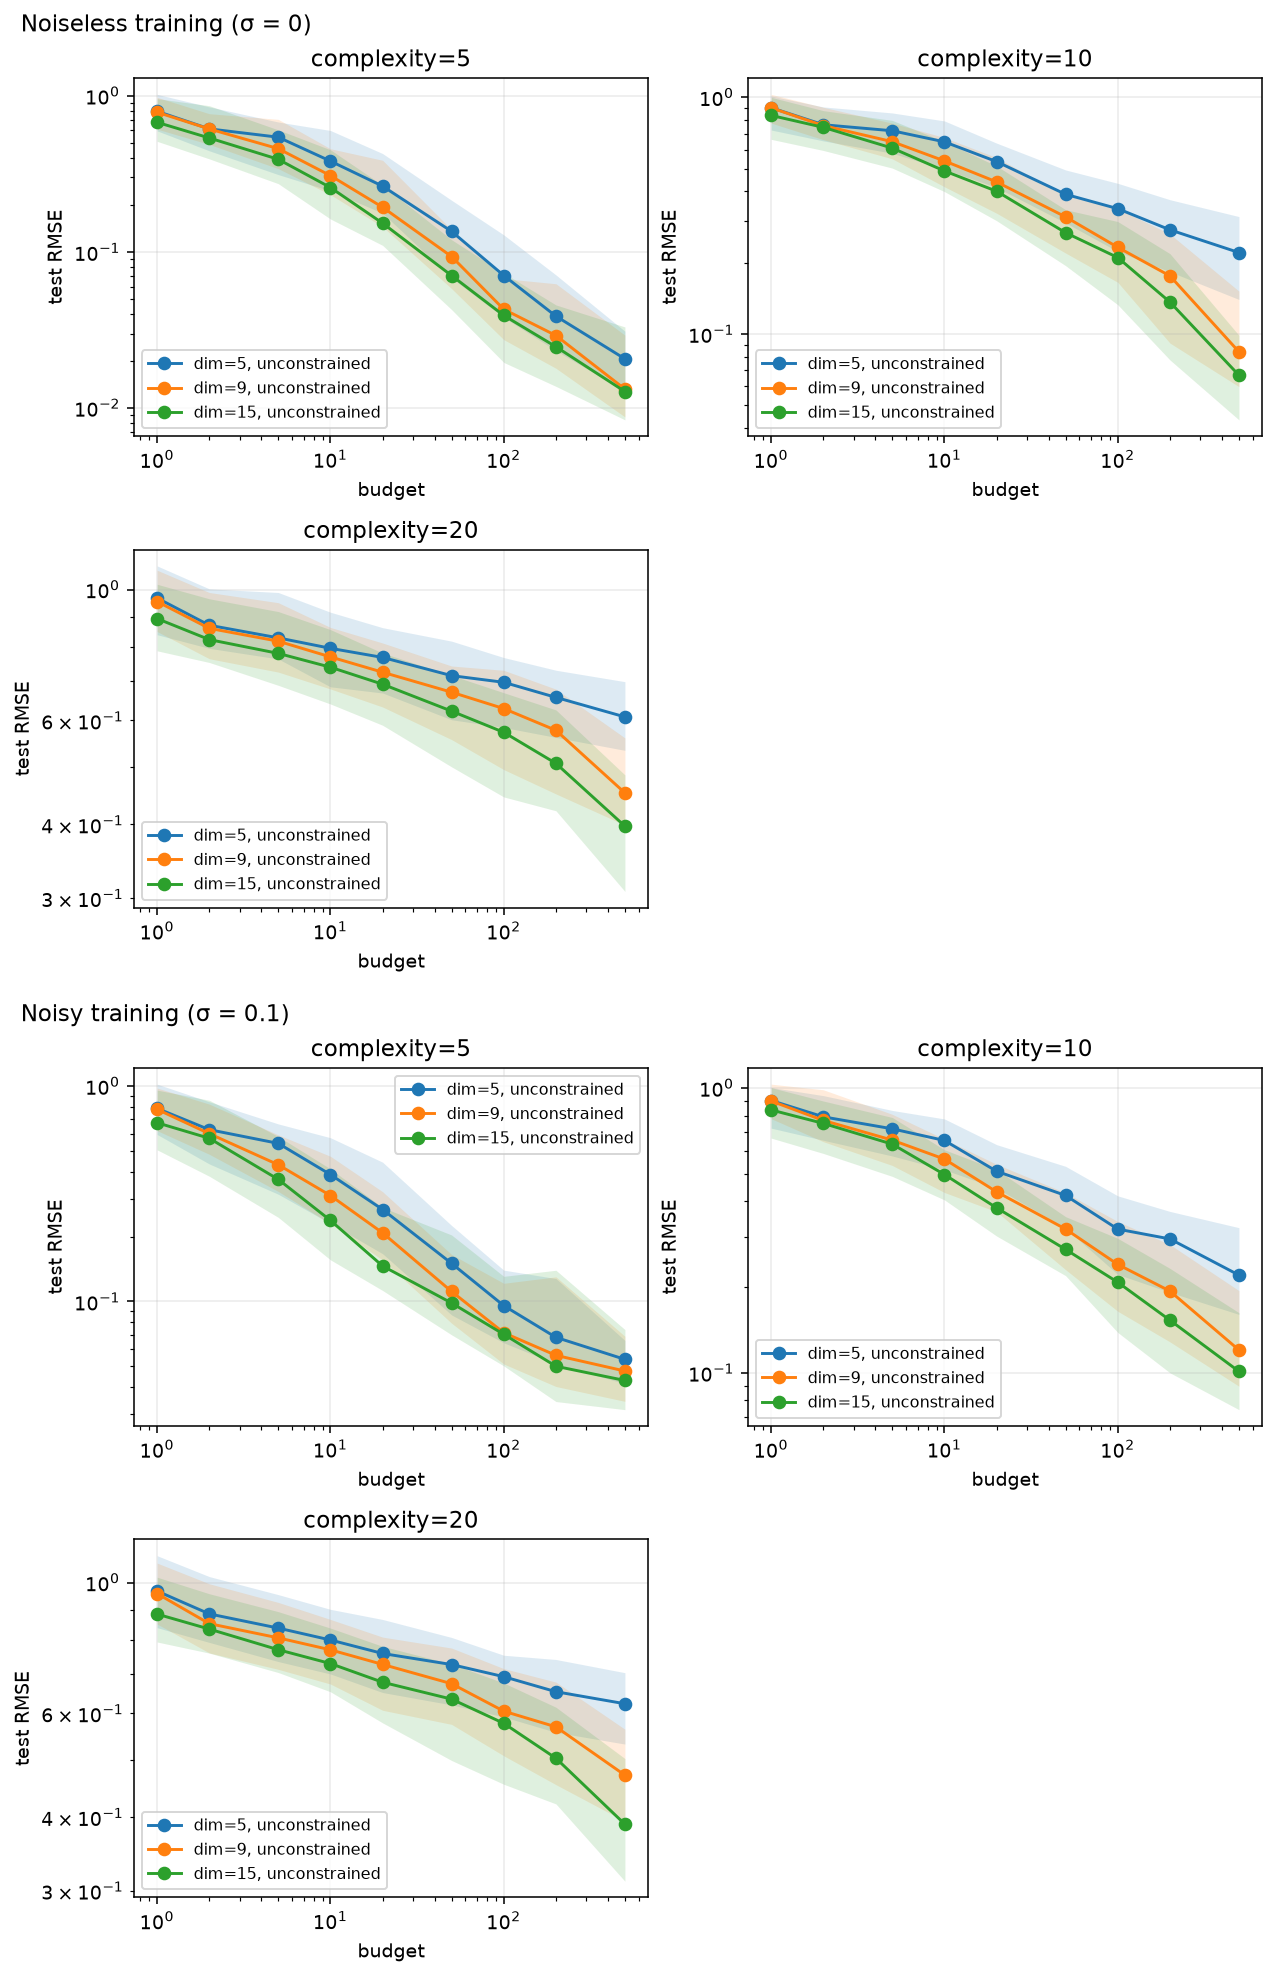

In [9]:
plot_scaling(plot_summary);

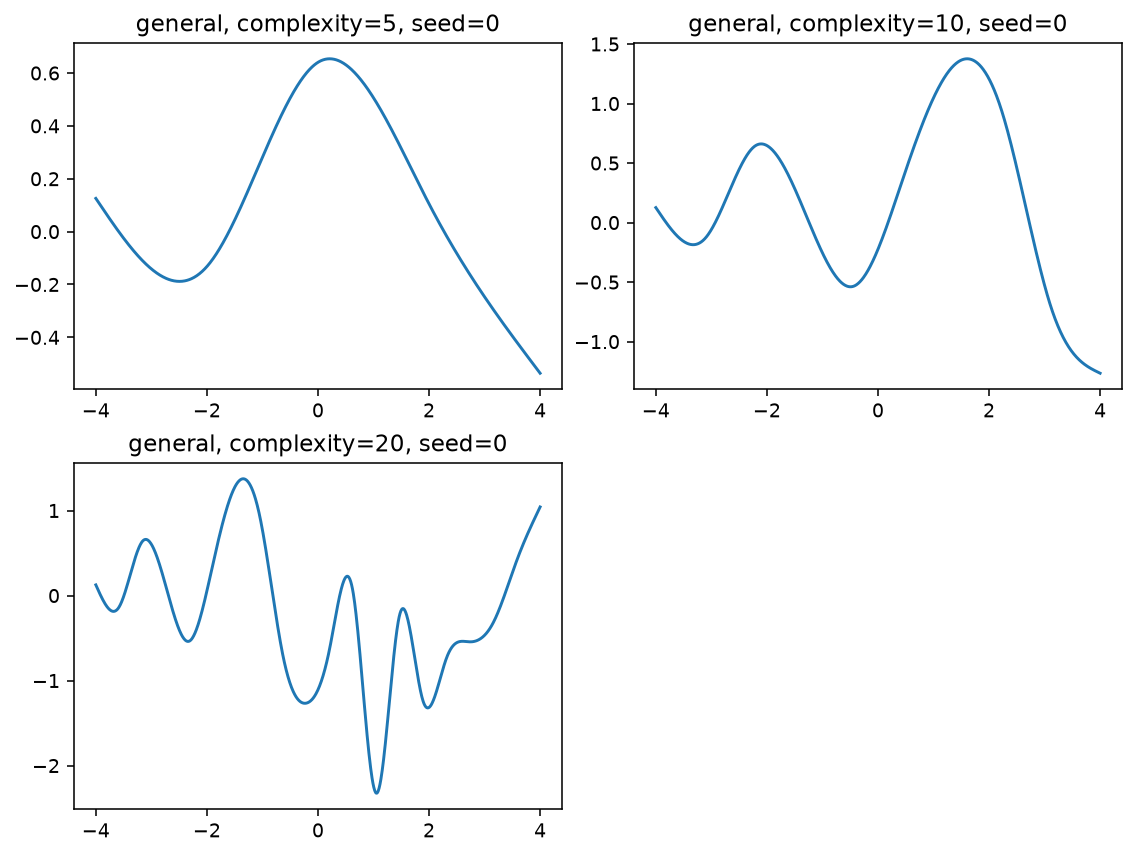

In [10]:
plot_target_gallery([
    TargetSpec(kind=plot_target_kind, complexity=complexity, seed=0)
    for complexity in profile.complexities
]);